# Lab 3-1: Downloading NAIP Aerial Imagery from Microsoft Planetary Computer

*Xiaojiang Li, University of Pennsylvania — updated for the Planetary Computer STAC API*

Before you can do **any** raster analysis — mosaicking, clipping, masking, computing NDVI — you need imagery on disk. This notebook builds the download step that the next two notebooks depend on: it finds every NAIP tile covering a study area, in a given year, and saves them to a local folder.

## What is NAIP?

The **National Agriculture Imagery Program** (NAIP) is aerial imagery flown by the USDA over the continental United States during the agricultural growing season. It is the workhorse dataset for fine-grained urban remote sensing in the US, for three reasons:

| Property | Value | Why it matters |
|---|---|---|
| Resolution | **0.6–1 m** per pixel | Individual trees, cars and building roofs are resolvable — Landsat's 30 m is not |
| Bands | **4: Red, Green, Blue, Near-Infrared** | The NIR band is what lets us separate vegetation from everything else |
| Revisit | every **2–3 years** per state | Good for change detection, too coarse for seasonal work |
| Cost | **free, public domain** | No licensing barrier for teaching or research |
| Tiling | ~3.75′ **quarter-quadrangles** | Each tile is ~165 MB; a city needs dozens of them |

### Band order — memorise this

NAIP GeoTIFFs store their bands in this order, and **rasterio indexes bands from 1, not 0**:

| Band index | Wavelength |
|---|---|
| `1` | Red |
| `2` | Green |
| `3` | Blue |
| `4` | Near-Infrared (NIR) |

Notebooks **3-2** and **3-3** read the tiles this notebook downloads and rely on exactly this order (`nir = dataset.read(4)`, `red = dataset.read(1)`). **Do not reorder the bands on disk.** "Colour-infrared" (CIR) is a way of *displaying* the data — you feed NIR, Red, Green into the screen's red, green, blue channels — not a different file. We cover that in section 7.

## What you will learn

1. What a **STAC** catalog is, and why modern satellite archives are searched rather than browsed
2. How to define an **area of interest** from a shapefile
3. How to **search** the Planetary Computer for NAIP scenes by location and date
4. How to **sign** asset URLs and download tiles to disk
5. How to wrap all of it in a **reusable function**
6. How to display a tile in **natural colour** and **colour-infrared**

## ⚠️ Before you run anything: disk space

**Each NAIP tile is roughly 165 MB, and Philadelphia takes about 46 tiles — close to 8 GB.** Downloading takes anywhere from several minutes to over an hour depending on your connection.

Plan accordingly:

* Make sure you have the space, and **do not put the output folder inside Dropbox / OneDrive / iCloud** — the sync client will try to upload all 8 GB.
* The download loop **skips files that already exist**, so it is safe to interrupt it and re-run.
* If you only want to try the workflow out, shrink the area of interest or set a limit on the number of tiles (see section 5).

## 0. Install the required packages

Three packages are specific to this notebook and are probably not in your environment yet:

| Package | What it does |
|---|---|
| `pystac-client` | Talks to a **STAC** catalog: search for imagery by place and date |
| `planetary-computer` | Signs Microsoft's asset URLs so they can be downloaded |
| `rioxarray` | Labelled arrays for raster data (used in later notebooks) |

Uncomment and run the appropriate cell below. `!` runs a shell command from inside the notebook, so you do not have to quit Jupyter to install something. **You do need to restart the kernel afterwards** (Kernel → Restart) before the new packages can be imported.

In [ ]:
# Inside a conda environment (preferred -- keeps conda's dependency solver happy):
# !conda install -c conda-forge pystac-client planetary-computer rioxarray -y

# Or with pip:
# !pip install pystac-client planetary-computer rioxarray

## 1. Imports

Grouped by what they are for, so you can see which library is doing which job.

In [1]:
# --- standard library ---------------------------------------------------
import os
import os.path
import glob
import urllib.request                      # downloads a URL to a local file

# --- searching and signing the Planetary Computer catalog ---------------
import pystac_client                       # STAC API client: search for imagery
import planetary_computer as pc            # signs Microsoft's asset URLs

# --- raster and vector I/O ----------------------------------------------
import rasterio as rio                     # read/write GeoTIFFs
import fiona                               # read/write vector files (shapefiles)
import geopandas as gpd                    # vector data as a table (used for a quick map)

# --- geometry and arrays -------------------------------------------------
import numpy as np
from shapely.geometry import shape, box, mapping   # build/convert geometries

# --- plotting -------------------------------------------------------------
from matplotlib import pyplot as plt

print("pystac_client:", pystac_client.__version__)

pystac_client: 0.9.0


## 2. Microsoft Planetary Computer and the STAC standard

Satellite and aerial archives are far too large to browse by folder — the NAIP collection alone is hundreds of terabytes. Instead they publish a **catalog you query**, using a standard called **STAC** (*SpatioTemporal Asset Catalog*).

Four STAC terms you need:

| Term | Meaning | In this notebook |
|---|---|---|
| **Catalog** | The whole searchable archive | Planetary Computer's `/api/stac/v1` |
| **Collection** | One dataset within it | `"naip"` (others: `"sentinel-2-l2a"`, `"landsat-c2-l2"`) |
| **Item** | One scene / tile, with its footprint, date and metadata | one NAIP quarter-quad |
| **Asset** | An actual downloadable file attached to an Item | `item.assets["image"]` → the GeoTIFF |

So the workflow is always the same: **open the catalog → search a collection by geometry + date → get back Items → download their Assets.** Learn it once and it transfers directly to Sentinel-2, Landsat, and everything else on the Planetary Computer.

Catalog browser: <https://planetarycomputer.microsoft.com/catalog>
NAIP dataset page: <https://planetarycomputer.microsoft.com/dataset/naip>

The catalog browser is worth clicking through once — it shows every collection, its date range and its footprint, which is often faster than guessing at search parameters:

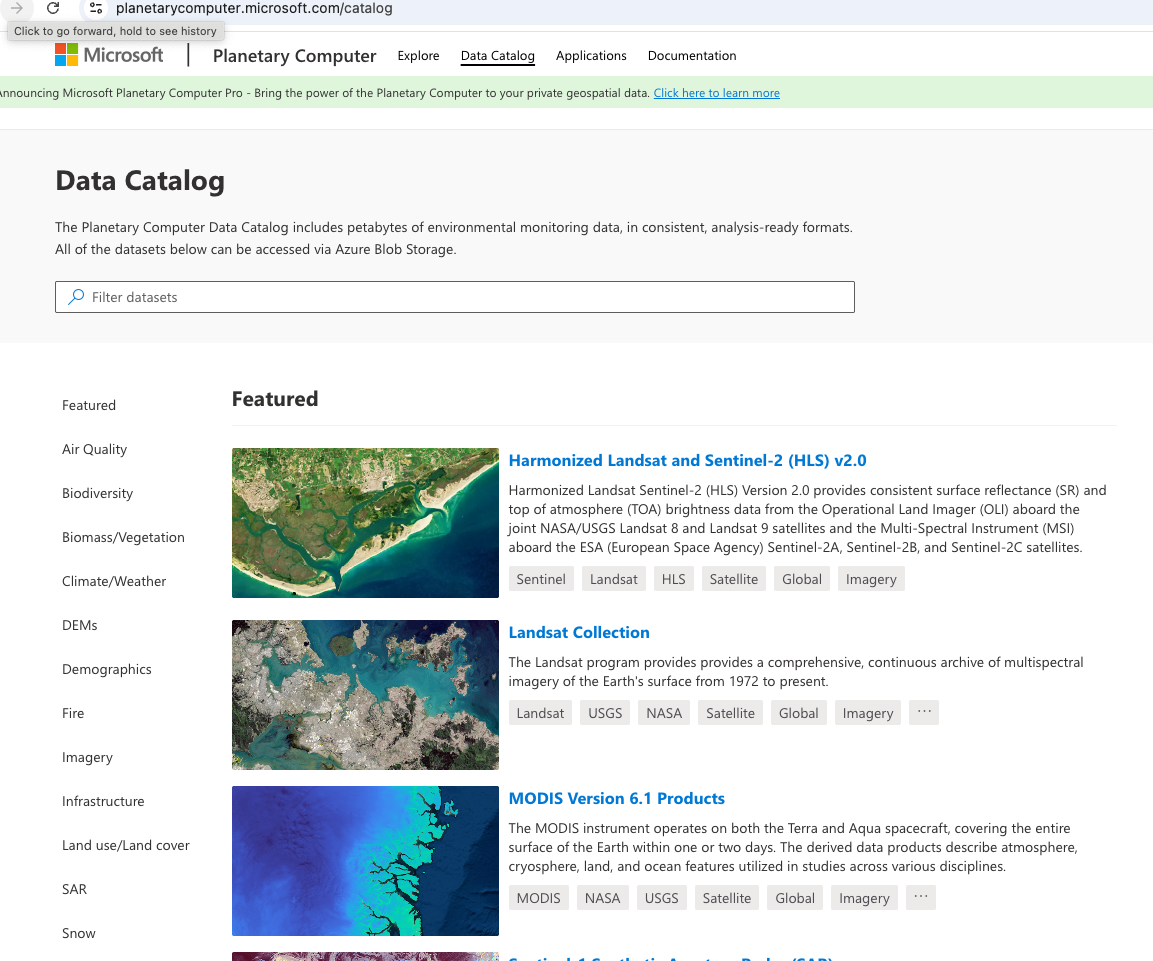

### 2.1 Signing: why a raw asset URL may not work

Planetary Computer stores its data in Azure Blob Storage. Many collections require a short-lived **SAS token** (Shared Access Signature) appended to the URL before Azure will serve the bytes. Getting that token is called **signing**.

The `planetary-computer` package handles this for you. Passing `modifier=planetary_computer.sign_inplace` when you open the catalog means **every asset URL that comes back is already signed** — you never have to think about tokens again.

**Do you need an account?** For NAIP, no — anonymous access works and is what this notebook uses. A free Planetary Computer subscription key only raises your rate limits, and some other collections require one. If you want one, request it here: <https://planetarycomputer.microsoft.com/docs/concepts/sas/>

The screenshot below shows what the token endpoint at <https://planetarycomputer.microsoft.com/api/sas/v1/token/naip> returns — a long string with an expiry time (`se=...`) baked into it:

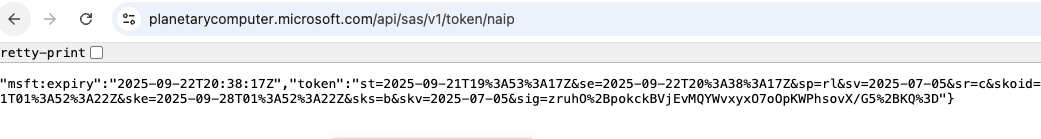

**A SAS token expires within hours.** Never hard-code one into a notebook, and never commit one to GitHub — it is a credential. Use the `PC_SDK_SUBSCRIPTION_KEY` environment variable instead, or simply let `sign_inplace` fetch a fresh token for you on every run, which is what we do here.

In [3]:
# OPTIONAL -- not needed for NAIP.
# A subscription key (not a SAS token!) raises your rate limits and unlocks a few
# restricted collections. Best practice is to keep it out of the notebook entirely:
#
#     export PC_SDK_SUBSCRIPTION_KEY="your-key-here"     # in your shell, before Jupyter
#
# planetary_computer reads that environment variable automatically. Only if you
# cannot set it should you fall back to setting it in code:
#
# pc.settings.set_subscription_key("<your subscription key>")

print("PC_SDK_SUBSCRIPTION_KEY is set:", "PC_SDK_SUBSCRIPTION_KEY" in os.environ)

PC_SDK_SUBSCRIPTION_KEY is set: False


## 3. Open the catalog

`sign_inplace` is the important argument here — without it, `item.assets["image"].href` gives you an unsigned URL that may be rejected by Azure.

In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,   # every asset URL comes back ready to download
)

catalog

<Client id=microsoft-pc>

## 4. Define the area of interest

The search needs a geometry saying *where* to look. Two rules:

1. **The geometry must be in EPSG:4326 (longitude/latitude).** STAC always speaks WGS 84 — that is why the input file here is named `city_limit_4326.shp`. If yours is projected, reproject it first with `gpd.read_file(...).to_crs("EPSG:4326")`.
2. **We use the bounding box, not the exact city outline.** A bounding box is a rectangle around the shape, so it also covers the corners outside the city limit. That means we will retrieve a few tiles that do not actually touch Philadelphia — harmless for now, and section 6 shows how to filter them out before downloading 165 MB of nothing.

In [7]:
shpfile = 'data/city_limit_4326.shp'

# fiona opens a vector file as a stream of features. Using `with` closes it for us.
with fiona.open(shpfile) as lyr:
    print("CRS of the input file:", lyr.crs.to_string())   # must be EPSG:4326
    print("Number of features   :", len(lyr))

    # Convert every feature to a shapely geometry. Keeping them in a list (rather
    # than merging them) means this works for a boundary made of several polygons.
    city_parts = [shape(feat['geometry']) for feat in lyr]

    # .bounds gives the extent of the whole layer: (minx, miny, maxx, maxy)
    left, bottom, right, top = lyr.bounds

print("\nBounding box (lon/lat):", (left, bottom, right, top))

# shapely's box() builds the rectangle; mapping() converts it to the GeoJSON dict
# that the STAC API expects.
area_of_interest = mapping(box(left, bottom, right, top))
area_of_interest

CRS of the input file: EPSG:4326
Number of features   : 1

Bounding box (lon/lat): (-75.28030313034645, 39.867465570687145, -74.9557457320632, 40.137927528193686)


{'type': 'Polygon',
 'coordinates': (((-74.9557457320632, 39.867465570687145),
   (-74.9557457320632, 40.137927528193686),
   (-75.28030313034645, 40.137927528193686),
   (-75.28030313034645, 39.867465570687145),
   (-74.9557457320632, 39.867465570687145)),)}

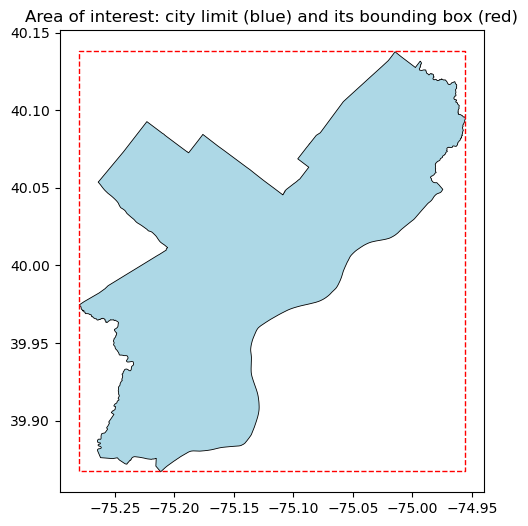

In [8]:
# Sanity check: draw the city outline inside its bounding box.
# Always look at your AOI before firing off an 8 GB download.
fig, ax = plt.subplots(figsize=(6, 6))

gpd.read_file(shpfile).plot(ax=ax, color="lightblue", edgecolor="black", linewidth=0.6)
gpd.GeoSeries([box(left, bottom, right, top)], crs="EPSG:4326").boundary.plot(
    ax=ax, color="red", linestyle="--", linewidth=1
)

ax.set_title("Area of interest: city limit (blue) and its bounding box (red)")
plt.show()

## 5. Search for NAIP tiles

NAIP is re-flown only every two or three years, and different states are flown in different years — so you must give the search a **date range** rather than a single date. STAC wants it as a single string, `"START/END"`, in `YYYY-MM-DD` form.

**How do you know which years exist for your area?** Two easy ways:

* Browse the Planetary Computer's [NAIP dataset page](https://planetarycomputer.microsoft.com/dataset/naip).
* Check the [Earth Engine NAIP catalog](https://developers.google.com/earth-engine/datasets/catalog/USDA_NAIP_DOQQ), which shows availability on a map:

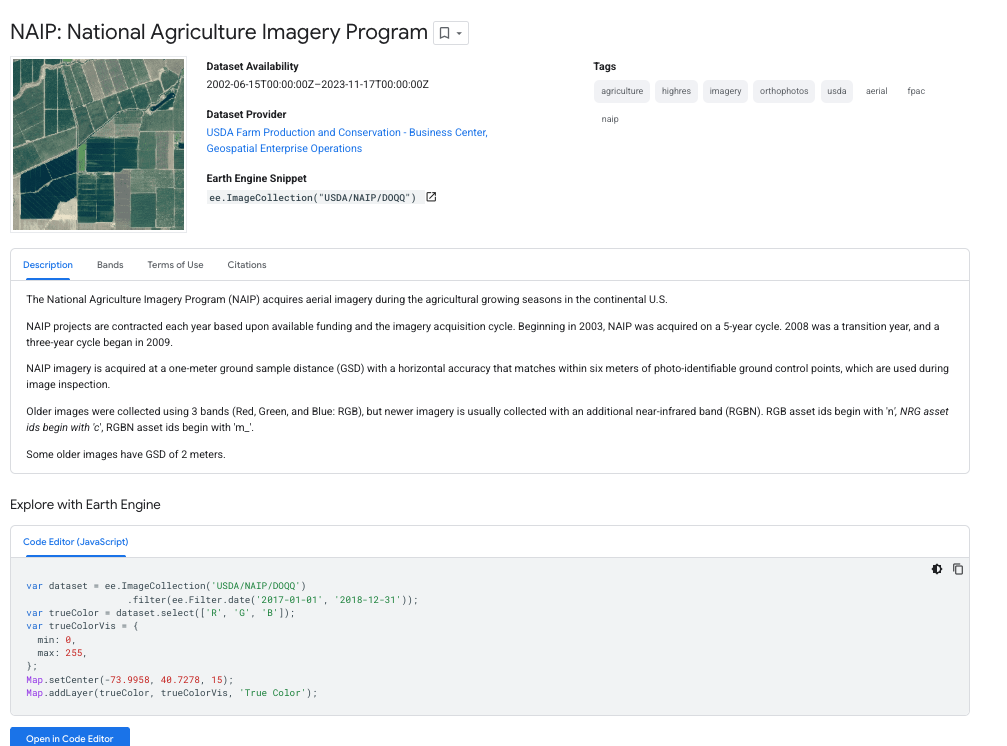

If your search returns **0 items**, that is almost always the reason: no NAIP flight over your area in the window you asked for. Widen the range to a whole year, or try 2015 / 2017 / 2019 / 2021.

Here we use summer 2017, which matches the imagery used in notebooks 3-2 and 3-3.

In [9]:
startDate = '2017-06-01'
endDate   = '2017-09-30'
range_time = f"{startDate}/{endDate}"     # STAC wants a single "START/END" string

search = catalog.search(
    collections=["naip"],          # which dataset
    intersects=area_of_interest,   # where  (GeoJSON geometry, EPSG:4326)
    datetime=range_time,           # when
)

# .item_collection() actually sends the request and pages through all the results.
# (Older tutorials call .get_items() -- that name is deprecated.)
items_tiles = search.item_collection()

print(f"{len(items_tiles)} NAIP tiles found for {range_time}")

46 NAIP tiles found for 2017-06-01/2017-09-30


### 5.1 Inspect the results *before* downloading

A search result is metadata only — nothing has been downloaded yet. This is the moment to check that you found what you expected, and to work out how big the download will be.

In [10]:
# Look at a single Item to see what the catalog knows about it
item = items_tiles[0]

print("id       :", item.id)
print("date     :", item.datetime.date())
print("state    :", item.properties.get("naip:state"))
print("gsd      :", item.properties.get("gsd"), "m per pixel")
print("assets   :", list(item.assets))
print("\nimage href (signed, truncated):")
print(item.assets["image"].href[:120], "...")

id       : pa_m_4007562_se_18_1_20170910_20171207
date     : 2017-09-10
state    : pa
gsd      : 1.0 m per pixel
assets   : ['image', 'metadata', 'thumbnail', 'tilejson', 'rendered_preview']

image href (signed, truncated):
https://naipeuwest.blob.core.windows.net/naip/v002/pa/2017/pa_100cm_2017/40075/m_4007562_se_18_1_20170910.tif?st=2026-09 ...


In [11]:
# How much data are we about to pull down?
# The catalog does not report file size, so use ~165 MB per NAIP tile as a rule of thumb.
MB_PER_TILE = 165
print(f"{len(items_tiles)} tiles x ~{MB_PER_TILE} MB "
      f"= roughly {len(items_tiles) * MB_PER_TILE / 1024:.1f} GB")

# Which acquisition dates are in the result? NAIP tiles for one city are often
# flown across several days, which is why a mosaic can show visible seams.
dates = sorted({i.datetime.date().isoformat() for i in items_tiles})
print("\nacquisition dates:", dates)

46 tiles x ~165 MB = roughly 7.4 GB

acquisition dates: ['2017-06-11', '2017-06-12', '2017-07-30', '2017-07-31', '2017-08-01', '2017-08-09', '2017-08-24', '2017-09-10']


## 6. Download the tiles

Now the actual download. Two details worth reading the code for:

* **`if os.path.exists(...): continue`** — skip anything already on disk. This makes the cell *restartable*: if your connection drops halfway through, just run it again and it picks up where it stopped.
* **We keep the file exactly as NAIP publishes it** (bands 1–4 = Red, Green, Blue, NIR). Notebooks 3-2 and 3-3 depend on that order.

The folder is called `cir-naip` for historical reasons — the tiles inside are ordinary 4-band NAIP GeoTIFFs, not colour-infrared files.

> 💡 **Testing the workflow?** Uncomment the `MAX_TILES` line to grab just a couple of tiles instead of all 46.

In [12]:
outfolder = 'cir-naip'
os.makedirs(outfolder, exist_ok=True)   # exist_ok=True: no error if it is already there

MAX_TILES = None      # set to e.g. 2 to try the workflow out without an 8 GB download
to_download = items_tiles[:MAX_TILES] if MAX_TILES else items_tiles

for n, item in enumerate(to_download, start=1):
    outfilename = os.path.join(outfolder, item.id + ".tif")

    # Already have it? Move on. This is what makes the cell safe to re-run.
    if os.path.exists(outfilename):
        print(f"[{n}/{len(to_download)}] {item.id} -- already on disk, skipping")
        continue

    # The href is already signed, because we opened the catalog with sign_inplace
    href = item.assets["image"].href

    print(f"[{n}/{len(to_download)}] downloading {item.id} ...")
    urllib.request.urlretrieve(href, outfilename)

print("\nDone.")

[1/46] downloading pa_m_4007562_se_18_1_20170910_20171207 ...
[2/46] downloading pa_m_4007562_ne_18_1_20170910_20171207 ...


KeyboardInterrupt: 

## 7. Wrap it in a function

The cells above are fine for exploring, but the logic is scattered across the notebook and hard-wired to one city and one year. Packaging it into a **function** makes it reusable: your homework city, a different year, a colleague's study area — all just different arguments.

Two improvements over the step-by-step version:

1. **It filters tiles before downloading them.** Each STAC Item carries its own footprint in `item.geometry`, so we can test `tile.intersects(city)` against the *real* city outline while the tile is still just metadata. Tiles that only touch the bounding-box corners are skipped, saving a 165 MB download each. The earlier approach — download first, check second, delete — wastes bandwidth.
2. **We test against every part of the boundary** with `any(...)`, instead of merging them into one polygon first. A city limit is often a multi-part shape (Philadelphia's includes river islands), and this avoids depending on shapely's set operations.
3. **Both geometries are already in EPSG:4326** (the STAC footprint always is, and we required the shapefile to be), so the intersection test needs no reprojection. If instead you compared against a *downloaded raster's* bounds, you would have to reproject first, because NAIP GeoTIFFs are stored in UTM (here EPSG:26918).

In [ ]:
def naip_downloader(shpfile, outfolder, startDate, endDate,
                    skip_existing=True, max_tiles=None):
    """
    Download every NAIP tile that overlaps a study area, for a given date range.

    Tiles are saved unmodified, in NAIP's native band order:
        band 1 = Red, band 2 = Green, band 3 = Blue, band 4 = Near-Infrared

    Parameters
    ----------
    shpfile : str
        Path to a polygon shapefile of the study area. Must be in EPSG:4326.
    outfolder : str
        Folder to write the GeoTIFFs into. Created if it does not exist.
    startDate, endDate : str
        Date range to search, as 'YYYY-MM-DD' (e.g. '2017-06-01', '2017-09-30').
    skip_existing : bool
        If True, do not re-download tiles that are already in `outfolder`.
    max_tiles : int or None
        Stop after this many tiles. Useful for testing; None means download all.

    Returns
    -------
    list of str
        Paths of the tiles that now exist locally for this study area.
    """
    os.makedirs(outfolder, exist_ok=True)

    # --- 1. Read the study area, and build a bounding box for the search ---
    with fiona.open(shpfile) as lyr:
        if lyr.crs.to_string() != 'EPSG:4326':
            raise ValueError(
                f"{shpfile} is in {lyr.crs.to_string()}; STAC needs EPSG:4326. "
                "Reproject it first: gpd.read_file(f).to_crs('EPSG:4326')"
            )
        city_parts = [shape(feat['geometry']) for feat in lyr]
        left, bottom, right, top = lyr.bounds

    area_of_interest = mapping(box(left, bottom, right, top))

    # --- 2. Search the catalog -------------------------------------------
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace,      # sign every asset URL for us
    )
    items_tiles = catalog.search(
        collections=["naip"],
        intersects=area_of_interest,
        datetime=f"{startDate}/{endDate}",
    ).item_collection()

    print(f"{len(items_tiles)} tiles found for {startDate}/{endDate}")

    # --- 3. Keep only the tiles that really touch the study area ----------
    # item.geometry is the tile footprint in EPSG:4326, the same CRS as the study
    # area, so we can compare them directly -- and we do it BEFORE downloading.
    keep = [it for it in items_tiles
            if any(shape(it.geometry).intersects(part) for part in city_parts)]
    print(f"{len(keep)} of them actually intersect the study area "
          f"({len(items_tiles) - len(keep)} bounding-box-only tiles skipped)")

    if max_tiles:
        keep = keep[:max_tiles]

    # --- 4. Download ------------------------------------------------------
    downloaded = []
    for n, item in enumerate(keep, start=1):
        outfilename = os.path.join(outfolder, item.id + ".tif")

        if skip_existing and os.path.exists(outfilename):
            print(f"[{n}/{len(keep)}] {item.id} -- already on disk")
            downloaded.append(outfilename)
            continue

        print(f"[{n}/{len(keep)}] downloading {item.id} ...")
        urllib.request.urlretrieve(item.assets["image"].href, outfilename)
        downloaded.append(outfilename)

    print(f"\n{len(downloaded)} tiles available in '{outfolder}'")
    return downloaded

### 7.1 Call the function

Everything the download depends on is now in one place at the top of the cell — change these four values and you have a different study.

In [ ]:
shapefile  = 'data/city_limit_4326.shp'   # study area, must be EPSG:4326
cir_naips  = 'cir-naip'                   # where the tiles go
startDate  = '2017-06-01'                 # NAIP is flown in summer
endDate    = '2017-09-30'

tiles = naip_downloader(shapefile, cir_naips, startDate, endDate)

## 8. Look at a tile

Never trust a download you have not looked at. Two things to check: the georeferencing (CRS, bounds, resolution) and the pixels themselves.

Notice the CRS: NAIP tiles come in **UTM** (EPSG:26918 for Philadelphia — NAD 83 / UTM zone 18N), *not* in the lon/lat we used for searching. Units are metres, which is exactly what you want for measuring areas in the next notebook.

In [13]:
# Pick whatever tile is on disk rather than hard-coding a filename, so this cell
# works no matter which study area you downloaded.
tiffile = sorted(glob.glob(os.path.join('cir-naip', '*.tif')))[0]
print("Opening:", tiffile)

dataset = rio.open(tiffile)

print("CRS        :", dataset.crs)
print("Size       :", dataset.width, "x", dataset.height, "pixels")
print("Bands      :", dataset.count, dataset.dtypes)
print("Resolution :", dataset.res, "(metres per pixel)")
print("Bounds     :", dataset.bounds)
print("File size  :", os.path.getsize(tiffile) / 1e6, "MB")

Opening: cir-naip/pa_m_4007562_ne_18_1_20170910_20171207.tif
CRS        : EPSG:26918
Size       : 5951 x 7554 pixels
Bands      : 4 ('uint8', 'uint8', 'uint8', 'uint8')
Resolution : (1.0, 1.0) (metres per pixel)
Bounds     : BoundingBox(left=473049.0, bottom=4434424.0, right=479000.0, top=4441978.0)
File size  : 11.96032 MB


### 8.1 Reading at reduced resolution

A NAIP tile is about 7,500 x 6,000 pixels. Reading all four bands at full size takes ~180 MB of RAM per tile, and matplotlib cannot show that many pixels on screen anyway.

`out_shape` tells rasterio to **resample while reading**, so only the smaller array is ever built. Get in the habit — it is the difference between a plot that appears instantly and one that fills your memory.

In [14]:
dsfactor = 10                              # read 1 pixel in every 10
h = dataset.height // dsfactor
w = dataset.width  // dsfactor
print(f"Resampling {dataset.width}x{dataset.height} -> {w}x{h} for display")

# rasterio band indices start at 1
red   = dataset.read(1, out_shape=(h, w))
green = dataset.read(2, out_shape=(h, w))
blue  = dataset.read(3, out_shape=(h, w))
nir   = dataset.read(4, out_shape=(h, w))

for name, band in [("red", red), ("green", green), ("blue", blue), ("NIR", nir)]:
    print(f"{name:>5}: min={band.min():3d}  max={band.max():3d}  mean={band.mean():6.1f}")

Resampling 5951x7554 -> 595x755 for display
  red: min=  0  max=255  mean= 126.9
green: min=  0  max=255  mean= 149.4
 blue: min=  0  max=255  mean= 124.1
  NIR: min=  0  max=255  mean= 170.5


/var/folders/71/pbz44c1s167ggg_nfc4s_c480000gq/T/ipykernel_49729/1401709517.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  red   = dataset.read(1, out_shape=(h, w))
/var/folders/71/pbz44c1s167ggg_nfc4s_c480000gq/T/ipykernel_49729/1401709517.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  green = dataset.read(2, out_shape=(h, w))
/var/folders/71/pbz44c1s167ggg_nfc4s_c480000gq/T/ipykernel_49729/1401709517.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  blue  = dataset.read(3, out_shape=(h, w))
/var/folders/71/pbz44c1s167ggg_nfc4s_c480000gq/T/ipykernel_49729/1401709517.py:10:

### 8.2 Natural colour vs colour-infrared

The same four bands can be shown two ways. A screen has only three channels (red, green, blue), so displaying a 4-band image always means **choosing which three bands to send to which channel**:

| Composite | Screen R | Screen G | Screen B | What it looks like |
|---|---|---|---|---|
| **Natural colour** | Red (1) | Green (2) | Blue (3) | What your eye would see from a plane |
| **Colour-infrared (CIR)** | **NIR (4)** | Red (1) | Green (2) | **Vegetation glows bright red** |

Healthy leaves reflect very strongly in the near-infrared and absorb red light for photosynthesis. Pushing NIR into the display's red channel therefore makes vegetation the loudest thing in the image — which is why CIR has been the standard vegetation-mapping composite since the days of film. Water, which absorbs NIR almost completely, turns nearly black.

This is a **display** choice: the file on disk is unchanged.

`np.dstack` stacks the three 2-D arrays into one `(height, width, 3)` array, which is the shape matplotlib expects for a colour image.

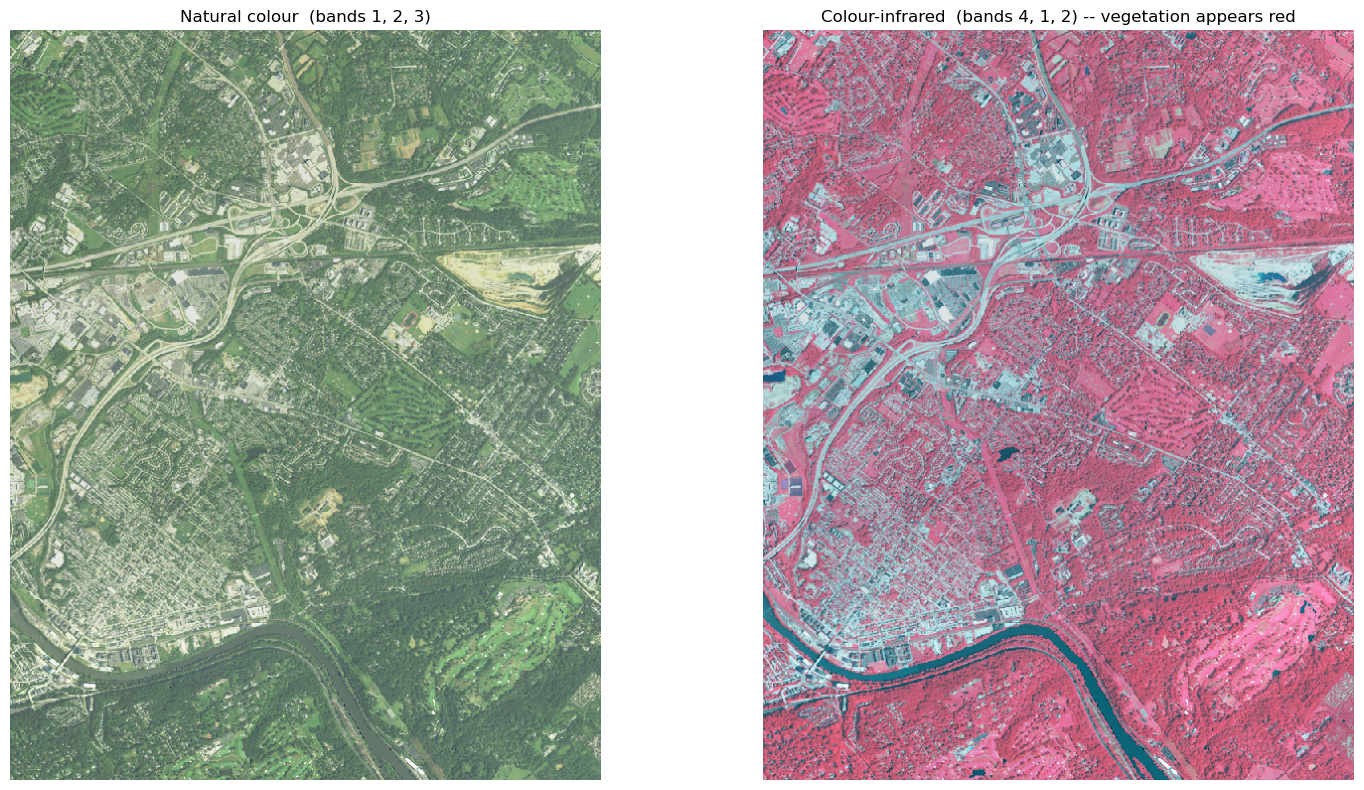

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Natural colour: R, G, B -> screen R, G, B
natural = np.dstack((red, green, blue))
axes[0].imshow(natural)
axes[0].set_title("Natural colour  (bands 1, 2, 3)")

# Colour-infrared: NIR, R, G -> screen R, G, B
cir = np.dstack((nir, red, green))
axes[1].imshow(cir)
axes[1].set_title("Colour-infrared  (bands 4, 1, 2) -- vegetation appears red")

for ax in axes:
    ax.set_axis_off()
plt.tight_layout()
plt.show()

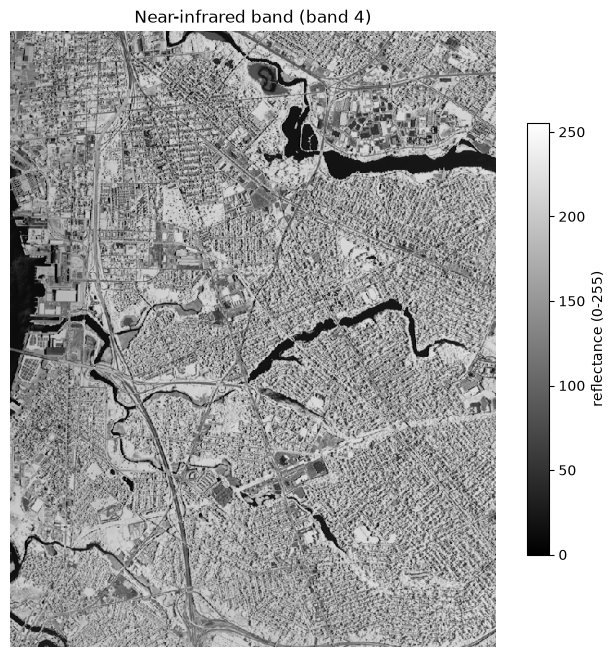

In [16]:
# A single band on its own is just a grey-scale array of numbers.
# NIR is the interesting one: bright = vegetation, dark = water and asphalt.
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(nir, cmap='gray')
ax.set_title("Near-infrared band (band 4)")
ax.set_axis_off()
plt.colorbar(im, ax=ax, shrink=0.7, label="reflectance (0-255)")
plt.show()

dataset.close()   # release the file handle when you are finished with it

## 9. Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| `0 Items found` | No NAIP flight over your area in that date window | Widen the range to a full year; check availability on the Earth Engine catalog |
| `ModuleNotFoundError: pystac_client` | Packages not installed, or kernel not restarted after installing | Run the install cell in section 0, then **restart the kernel** |
| `HTTP Error 403: Forbidden` | Unsigned or expired asset URL | Open the catalog with `modifier=pc.sign_inplace`; never reuse a saved SAS token |
| Download stalls or dies partway | Large files, unstable connection | Just re-run the cell — existing tiles are skipped |
| `ValueError: ... needs EPSG:4326` | Study-area shapefile is projected | `gpd.read_file(f).to_crs("EPSG:4326").to_file("aoi_4326.shp")` |
| `No space left on device` | ~8 GB of tiles | Free space, or use `max_tiles` / a smaller study area |
| NDVI looks wrong in notebook 3-2 | Bands were reordered on disk | Re-download; keep NAIP's native order (R, G, B, NIR) |
| Plot is a blank white rectangle | Reading a float array with values outside 0–255 | Keep the array as `uint8`, or normalise before `imshow` |

## What's next

* **Notebook 3-2 — raster data manipulation:** read these tiles with rasterio, compute NDVI from the red and NIR bands, and threshold it into a vegetation mask.
* **Notebook 3-3 — clip, mosaic, zonal analysis:** merge the tiles into one image, clip it to the city limit, and summarise green cover by census tract.

## References

1. Planetary Computer NAIP dataset — <https://planetarycomputer.microsoft.com/dataset/naip>
2. Planetary Computer SAS / authentication — <https://planetarycomputer.microsoft.com/docs/concepts/sas/>
3. The STAC specification — <https://stacspec.org/>
4. `pystac-client` documentation — <https://pystac-client.readthedocs.io/>
5. USDA NAIP program — <https://www.fsa.usda.gov/programs-and-services/aerial-photography/imagery-programs/naip-imagery/>
6. NAIP in Google Earth Engine (quick availability check) — <https://developers.google.com/earth-engine/datasets/catalog/USDA_NAIP_DOQQ>

## Try it yourself

1. **Change the study area.** Find a city-limit or county boundary for somewhere else, reproject it to EPSG:4326, and run `naip_downloader` with `max_tiles=2`. How many tiles would the full download need?
2. **Change the year.** Search the same area for 2015, 2019 and 2021. Which years actually have imagery, and how many tiles does each return?
3. **Read the metadata, not the pixels.** Without downloading anything, print each Item's `id`, date and footprint area, and identify the tile whose footprint overlaps the city outline the most.